In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 921.5/921.5 kB 34.5 MB/s eta 0:00:00


In [3]:
import numpy as np 
import pandas as pd  
import os
import keras_cv
import os
import math
import textwrap
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image
import numpy as np

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
 

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
/kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/data.yaml
/kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/valid/labels/Adam-Hills-Photography-Headshot-photographer-London_jpeg.rf.26145a35748b47798ff237308eae60e2.txt
/kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/valid/labels/Giamba_jpeg.rf.477b90411389f38dc345023fe9ed0226.txt
/kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/valid/labels/_-34-_jpeg.rf.5acaab5f96f8e85be6bd364303543a3a.txt
/kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/valid/labels/Versus-Versace_jp

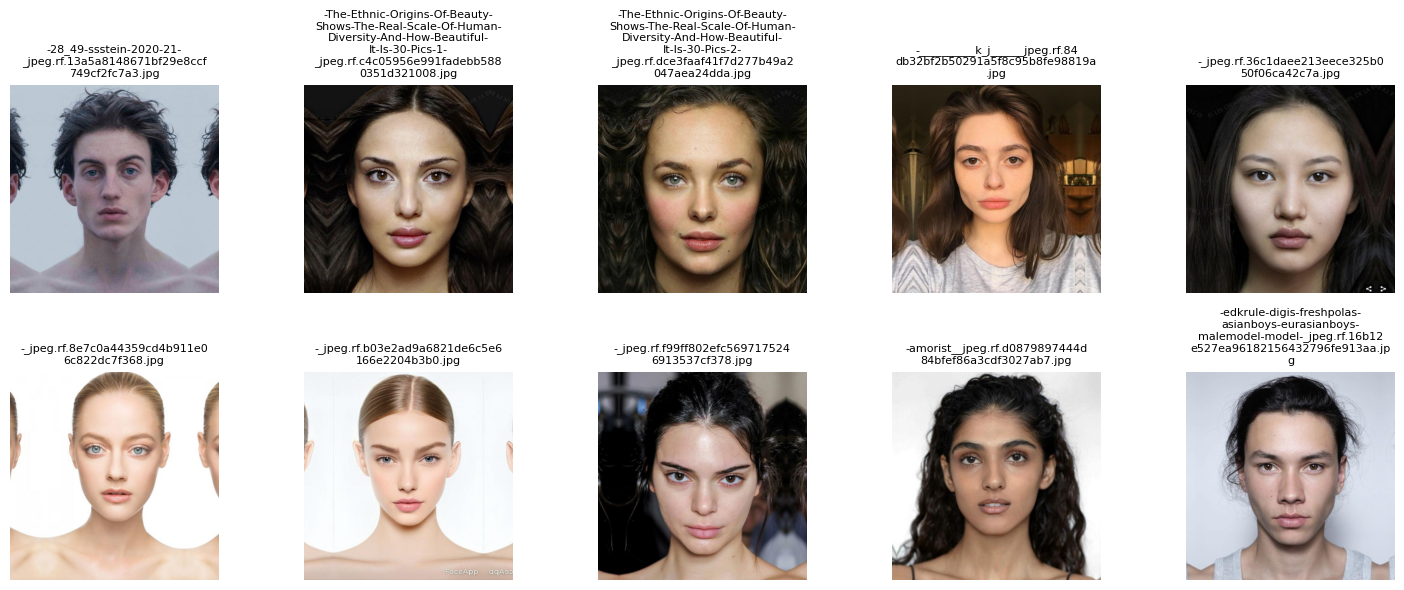

In [4]:
import os
import math
import textwrap
import matplotlib.pyplot as plt
from PIL import Image

train_images_dir = "/kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/train/images"

image_files = sorted([ f for f in os.listdir(train_images_dir) if f.endswith((".jpg", ".jpeg", ".png", ".webp")) ])

num_to_show = 10
images_per_row = 5

some_images = image_files[:num_to_show]

num_rows = math.ceil(num_to_show / images_per_row)

fig, axes = plt.subplots( nrows=num_rows, ncols=images_per_row, figsize=(3 * images_per_row, 3 * num_rows) )
 
axes = axes.ravel()

for i in range(num_to_show):
    img_name = some_images[i]
    img_path = os.path.join(train_images_dir, img_name)
    img = Image.open(img_path).convert("RGB")
     
    axes[i].imshow(img)
     
    wrapped_title = "\n".join(textwrap.wrap(img_name, width=30))
    axes[i].set_title(wrapped_title, fontsize=8)
    axes[i].axis("off")
 
for j in range(num_to_show, num_rows * images_per_row):
    axes[j].axis("off") 
    
plt.subplots_adjust(wspace=0.1, hspace=0.3)
plt.tight_layout()
plt.show()

In [5]:
!cat "/kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/data.yaml"

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['eye', 'eyebrow', 'lip', 'mustache-beard', 'nose']

roboflow:
  workspace: kagna-technologies-ddmoj
  project: extracting-facial-features
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/kagna-technologies-ddmoj/extracting-facial-features/dataset/1

In [6]:
base_dir = "/kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset"
data_yaml = os.path.join(base_dir, "data.yaml")
image_dir = os.path.join(base_dir, "valid/images")
train_dir = os.path.join(base_dir, "train/images")
val_dir = os.path.join(base_dir, "valid/images")
test_dir = os.path.join(base_dir, "test/images")

for path in [data_yaml, image_dir, train_dir, val_dir, test_dir]:
    if not os.path.exists(path):
        print(f"Error: {path} not found.")
        !ls "{base_dir}"
        raise FileNotFoundError(f"Adjust path based on output above.")

In [7]:
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith((".jpg", ".jpeg", ".png", ".webp"))])
image_files[0]

'-The-Ethnic-Origins-Of-Beauty-Shows-The-Real-Scale-Of-Human-Diversity-And-How-Beautiful-It-Is-30-Pics-_jpeg.rf.35e9a4d6bc2e3f70c24d727ecb95a35e.jpg'

In [12]:
model = YOLO("yolov8m.pt") 

import yaml
import torch 

with open(data_yaml, 'r') as f:
    data_config = yaml.safe_load(f)


data_config['train'] = train_dir
data_config['val'] = val_dir
data_config['test'] = test_dir


temp_yaml = "/kaggle/working/data_adjusted.yaml"
with open(temp_yaml, 'w') as f:
    yaml.safe_dump(data_config, f)

# Select device (GPU if available, else CPU)
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Fine-tune on your dataset
print("Fine-tuning YOLOv8 on facial features...")
model.train(
    data=temp_yaml,
    epochs=10,
    imgsz=640,
    batch=16,
    device=device,
    project="/kaggle/working/"
)

Using device: cuda:0
Fine-tuning YOLOv8 on facial features...
Ultralytics 8.3.78 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/kaggle/working/data_adjusted.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cuda:0, workers=8, project=/kaggle/working/, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=Fals

train: Scanning /kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/train/labels... 457 images, 0 backgrounds, 0 corrupt: 100%|██████████| 457/457 [00:00<00:00, 736.59it/s]

train: WARNING ⚠️ Cache directory /kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/train is not writeable, cache not saved.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/valid/labels... 126 images, 0 backgrounds, 0 corrupt: 100%|██████████| 126/126 [00:00<00:00, 363.94it/s]

val: WARNING ⚠️ Cache directory /kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/valid is not writeable, cache not saved.


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:02<00:00,  1.52it/s]


                   all        126        685      0.983      0.995      0.994      0.837
                   eye        126        138      0.964          1      0.993      0.838
               eyebrow        126        144       0.96      0.994      0.994      0.778
                   lip        126        129          1          1      0.995       0.87
        mustache-beard        126        146      0.992      0.993      0.995      0.833
                  nose        126        128          1      0.986      0.995      0.864


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 10.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a0e168e5d50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [9]:
model.save("/kaggle/working/yolov8m_finetuned.pt")
fine_tuned_model = YOLO("/kaggle/working/yolov8m_finetuned.pt")

In [13]:
# Process and visualize images
num_to_show = min(10, len(image_files))
images_per_row = 5
num_rows = math.ceil(num_to_show / images_per_row)

annotated_images = []
image_names = image_files[:num_to_show]

for img_name in image_names:
    img_path = os.path.join(image_dir, img_name)
    results = fine_tuned_model.predict(img_path, conf=0.1, augment=True, device=device)
    annotated_img = Image.fromarray(results[0].plot())
    annotated_images.append(annotated_img)


image 1/1 /kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/valid/images/-The-Ethnic-Origins-Of-Beauty-Shows-The-Real-Scale-Of-Human-Diversity-And-How-Beautiful-It-Is-30-Pics-_jpeg.rf.35e9a4d6bc2e3f70c24d727ecb95a35e.jpg: 640x640 1 eye, 1 eyebrow, 1 lip, 3 mustache-beards, 1 nose, 103.5ms
Speed: 3.9ms preprocess, 103.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/valid/images/-_jpeg.rf.6e0e9dbde936cea0cfb78e4bd9e15549.jpg: 640x640 1 eye, 1 eyebrow, 1 lip, 1 mustache-beard, 1 nose, 39.9ms
Speed: 2.8ms preprocess, 39.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/valid/images/-whoshalima_jpeg.rf.8429bdcfa43b87b025b996251b05b8fc.jpg: 640x640 1 eye, 1 eyebrow, 1 lip, 1 mustache-beard, 1 nose, 40.4ms
Speed: 1.4ms preprocess, 40.4ms 

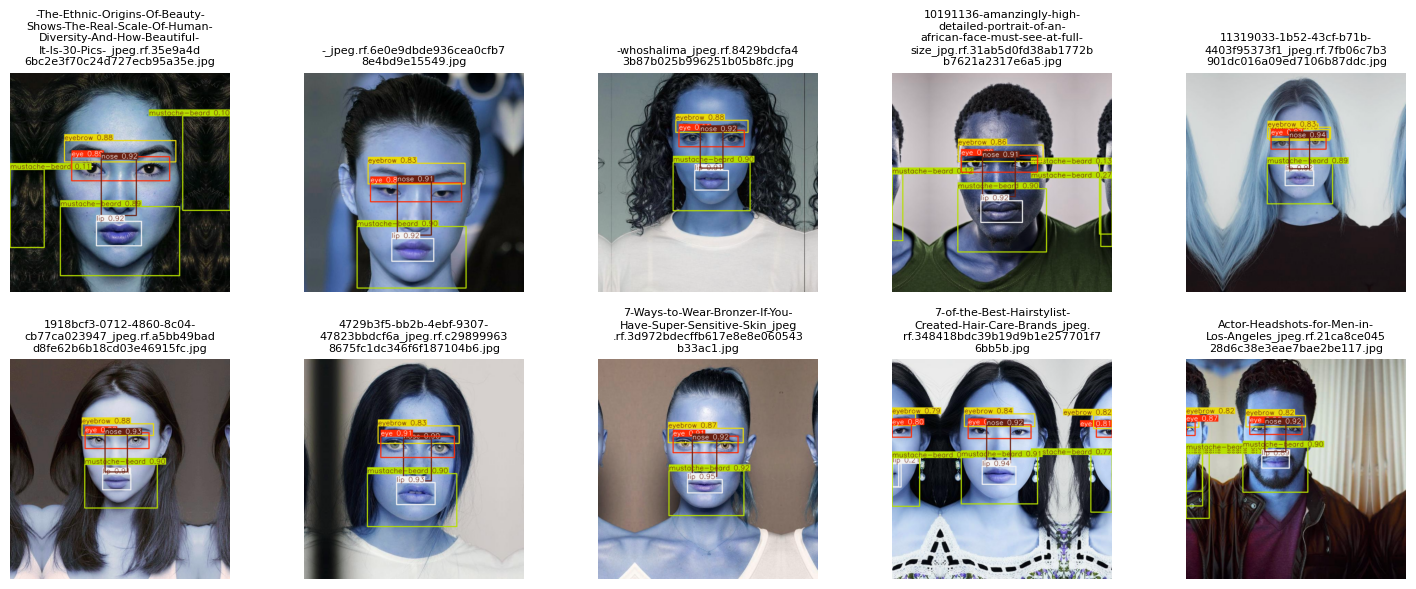

In [14]:
# Visualize in a grid
fig, axes = plt.subplots(nrows=num_rows, ncols=images_per_row, figsize=(3 * images_per_row, 3 * num_rows))
axes = axes.ravel()

for i in range(num_to_show):
    img = annotated_images[i]
    img_name = image_names[i]
    
    axes[i].imshow(img)
    wrapped_title = "\n".join(textwrap.wrap(img_name, width=30))
    axes[i].set_title(wrapped_title, fontsize=8)
    axes[i].axis("off")

for j in range(num_to_show, num_rows * images_per_row):
    axes[j].axis("off")

plt.subplots_adjust(wspace=0.1, hspace=0.3)
plt.tight_layout()
plt.show()

In [15]:
print("\nDetected Features in Each Image:")
for i, result in enumerate([fine_tuned_model.predict(os.path.join(image_dir, name), conf=0.1, augment=True, device=device)[0] for name in image_names]):
    print(f"\nImage: {image_names[i]}")
    for box in result.boxes:
        label = result.names[int(box.cls)]
        confidence = box.conf.item()
        x, y, w, h = [v.item() for v in box.xywh[0]]
        print(f"Feature: {label}, Confidence: {confidence:.2f}, Box: (x:{x:.1f}, y:{y:.1f}, w:{w:.1f}, h:{h:.1f})")


Detected Features in Each Image:

image 1/1 /kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/valid/images/-The-Ethnic-Origins-Of-Beauty-Shows-The-Real-Scale-Of-Human-Diversity-And-How-Beautiful-It-Is-30-Pics-_jpeg.rf.35e9a4d6bc2e3f70c24d727ecb95a35e.jpg: 640x640 1 eye, 1 eyebrow, 1 lip, 3 mustache-beards, 1 nose, 43.8ms
Speed: 1.9ms preprocess, 43.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/valid/images/-_jpeg.rf.6e0e9dbde936cea0cfb78e4bd9e15549.jpg: 640x640 1 eye, 1 eyebrow, 1 lip, 1 mustache-beard, 1 nose, 44.0ms
Speed: 1.8ms preprocess, 44.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset/valid/images/-whoshalima_jpeg.rf.8429bdcfa43b87b025b996251b05b8fc.jpg: 640x640 1 eye, 1 eyebrow, 1 lip, 1 mustache-beard, 1 nose, 47.2ms


The pipeline was designed to transform a set of headshot images from the `Facial Feature Extraction Dataset` into a detailed facial feature detection system using YOLOv8. Initially, applying the pre-trained YOLOv8 model (`yolov8m.pt`) to the headshots resulted in broad bounding boxes encompassing the entire person, labeled as "human." This occurred because the pre-trained model was built on the COCO dataset, which includes 80 general classes such as "person," "car," or "dog," but lacks specific labels for facial features like eyes, noses, or lips. This generic detection was insufficient for the goal of identifying individual facial components within the headshots.

The dataset, however, provided a critical advantage: a `data.yaml` file and corresponding label files (e.g., `Adam-Hills-Photography-...txt`) that contained detailed annotations for facial features—specifically `eye`, `eyebrow`, `lip`, `mustache-beard`, and `nose`. These annotations, formatted in YOLO style (class ID, x_center, y_center, width, height), enabled a shift toward more precise detection. The pipeline began by establishing the environment, installing the Ultralytics package for YOLOv8 and importing libraries like `torch`, `matplotlib`, and `PIL` to facilitate model training, image processing, and visualization. Paths to the dataset within Kaggle’s structure (`/kaggle/input/facial-feature-extraction-dataset/Facial Feature Extraction Dataset`) were defined and verified, ensuring access to `data.yaml` and the `train`, `valid`, and `test` image directories. A sorted list of validation images was then compiled to focus on a manageable subset for visualization.

The pivotal step involved loading the pre-trained YOLOv8 medium model and fine-tuning it. The original `data.yaml` contained relative paths (`../train/images`, etc.), which were incompatible with Kaggle’s read-only `/kaggle/input/` directory. To resolve this, the paths were converted to absolute ones (e.g., `/kaggle/input/.../train/images`), and a new `data_adjusted.yaml` was created and saved in Kaggle’s writable `/kaggle/working/` directory. A device selection mechanism determined whether a GPU (`cuda:0`) or CPU was available, ensuring the pipeline could adapt to Kaggle’s hardware constraints. The fine-tuning process then trained the model on the dataset for 10 epochs, leveraging the facial feature annotations to refine its weights and shift its focus from detecting "person" to recognizing specific features like eyes and noses.

Once fine-tuning was complete, the updated model was saved as `yolov8m_finetuned.pt` and reloaded for inference. Up to 10 validation images were processed with this fine-tuned model, using a low confidence threshold (`0.1`) and test-time augmentation to maximize feature detection, even for less certain predictions. The resulting images, now annotated with bounding boxes around facial features, were visualized in a grid using `matplotlib`, with filenames displayed as wrapped titles for clarity. Additionally, a text output detailed each detection, listing the identified features, their confidence scores, and bounding box coordinates.

Ultimately, the pipeline converted a general-purpose object detector, initially limited to broad "human" classifications, into a specialized system capable of pinpointing facial features in headshots. This transformation was driven by the dataset’s annotations and the fine-tuning process, culminating in a visual and textual representation of precise feature detection tailored to the headshot images.